# P661 - Project: Bankruptcy Prevention



Business Objective:

This is a classification project, since the variable to predict is binary (bankruptcy or non-bankruptcy). The goal here is to model the probability that a business goes bankrupt from different features.

The data file contains 7 features about 250 companies

The data set includes the following variables:

1.	industrial_risk: 0=low risk, 0.5=medium risk, 1=high risk.

2.	management_risk: 0=low risk, 0.5=medium risk, 1=high risk.

3.	financial flexibility: 0=low flexibility, 0.5=medium flexibility, 1=high flexibility.

4.	credibility: 0=low credibility, 0.5=medium credibility, 1=high credibility.

5.	competitiveness: 0=low competitiveness, 0.5=medium competitiveness, 1=high competitiveness.

6.	operating_risk: 0=low risk, 0.5=medium risk, 1=high risk.

7.	class: bankruptcy, non-bankruptcy (target variable).


Acceptance Criterion:

Need to deploy the end results using Streamlit.etc.


# Packages

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
plt.style.use('ggplot')

In [ ]:
from sklearn.model_selection import train_test_split,GridSearchCV,cross_validate,StratifiedShuffleSplit

In [ ]:
from sklearn.feature_selection import f_classif

In [ ]:
from sklearn.linear_model import LogisticRegressionCV,LogisticRegression

In [ ]:
from sklearn.tree import DecisionTreeClassifier

In [ ]:
from sklearn.ensemble import RandomForestClassifier,AdaBoostClassifier,BaggingClassifier,GradientBoostingClassifier

In [ ]:
import xgboost as xgb

In [ ]:
import lightgbm as lgb

In [ ]:
from sklearn.metrics import classification_report,accuracy_score,precision_recall_fscore_support,roc_curve,roc_auc_score

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [ ]:
from sklearn.svm import SVC

In [ ]:
!pip install streamlit
import streamlit as st

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 59.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 93.5 MB/s eta 0:00:00


In [ ]:
import pickle

In [ ]:
import getpass

In [ ]:
!pip install streamlit pyngrok

# Dataset

In [ ]:
# Loading the Dataset
df=pd.read_excel('/content/bankruptcy-prevention.xlsx')
df.head()

,industrial_risk; management_risk; financial_flexibility; credibility; competitiveness; operating_risk; class
0,0.5;1;0;0;0;0.5;bankruptcy
1,0;1;0;0;0;1;bankruptcy
2,1;0;0;0;0;1;bankruptcy
3,0.5;0;0;0.5;0;1;bankruptcy
4,1;1;0;0;0;1;bankruptcy


In [ ]:
# Splitting the column using the delimiter ';'
df=df.iloc[:,0].str.split(';',expand=True)
df.head()

,0,1,2,3,4,5,6
0,0.5,1,0,0,0,0.5,bankruptcy
1,0,1,0,0,0,1,bankruptcy
2,1,0,0,0,0,1,bankruptcy
3,0.5,0,0,0.5,0,1,bankruptcy
4,1,1,0,0,0,1,bankruptcy


In [ ]:
# Adding column heading
df.columns=['industrial_risk','management_risk','financial_flexibility','credibility','competitiveness','operating_risk','class']
df.head()

,industrial_risk,management_risk,financial_flexibility,credibility,competitiveness,operating_risk,class
0,0.5,1,0,0,0,0.5,bankruptcy
1,0,1,0,0,0,1,bankruptcy
2,1,0,0,0,0,1,bankruptcy
3,0.5,0,0,0.5,0,1,bankruptcy
4,1,1,0,0,0,1,bankruptcy


In [ ]:
data=df.copy()

# Exploratory Data Analysis

In [ ]:
df.info()
# No null values found

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   industrial_risk        250 non-null    object
 1   management_risk        250 non-null    object
 2   financial_flexibility  250 non-null    object
 3   credibility            250 non-null    object
 4   competitiveness        250 non-null    object
 5   operating_risk         250 non-null    object
 6   class                  250 non-null    object
dtypes: object(7)
memory usage: 13.8+ KB


In [ ]:
# Checking for Duplicates
print(df.duplicated().sum())
df.drop_duplicates(inplace=True)

147


In [ ]:
# Unique values in each Column
for x in df.columns:
  print(x)
  print(df[x].unique())

industrial_risk
['0.5' '0' '1']
management_risk
['1' '0' '0.5']
financial_flexibility
['0' '0.5' '1']
credibility
['0' '0.5' '1']
competitiveness
['0' '0.5' '1']
operating_risk
['0.5' '1' '0']
class
['bankruptcy' 'non-bankruptcy']


In [ ]:
# Labelling the Target column
# Bankrupt = 1
# Non Bankrupt = 0

df['class']=df['class'].apply(lambda x:1 if x=='bankruptcy' else 0)

# Changing the datatype of the columns
for x in df.columns:
  df[x]=df[x].astype('float')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 103 entries, 0 to 194
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   industrial_risk        103 non-null    float64
 1   management_risk        103 non-null    float64
 2   financial_flexibility  103 non-null    float64
 3   credibility            103 non-null    float64
 4   competitiveness        103 non-null    float64
 5   operating_risk         103 non-null    float64
 6   class                  103 non-null    float64
dtypes: float64(7)
memory usage: 6.4 KB


In [ ]:
dff=df.copy()
dff.head()

,industrial_risk,management_risk,financial_flexibility,credibility,competitiveness,operating_risk,class
0,0.5,1.0,0.0,0.0,0.0,0.5,1.0
1,0.0,1.0,0.0,0.0,0.0,1.0,1.0
2,1.0,0.0,0.0,0.0,0.0,1.0,1.0
3,0.5,0.0,0.0,0.5,0.0,1.0,1.0
4,1.0,1.0,0.0,0.0,0.0,1.0,1.0


In [ ]:
# Replacing number for visualisation
dff['industrial_risk']=dff['industrial_risk'].apply(lambda x:'Low' if x==0 else 'Medium' if x==0.5 else 'High')
dff['management_risk']=dff['management_risk'].apply(lambda x:'Low' if x==0 else 'Medium' if x==0.5 else 'High')
dff['financial_flexibility']=dff['financial_flexibility'].apply(lambda x:'Low' if x==0 else 'Medium' if x==0.5 else 'High')
dff['credibility']=dff['credibility'].apply(lambda x:'Low' if x==0 else 'Medium' if x==0.5 else 'High')
dff['competitiveness']=dff['competitiveness'].apply(lambda x:'Low' if x==0 else 'Medium' if x==0.5 else 'High')
dff['operating_risk']=dff['operating_risk'].apply(lambda x:'Low' if x==0 else 'Medium' if x==0.5 else 'High')
dff.head()

,industrial_risk,management_risk,financial_flexibility,credibility,competitiveness,operating_risk,class
0,Medium,High,Low,Low,Low,Medium,1.0
1,Low,High,Low,Low,Low,High,1.0
2,High,Low,Low,Low,Low,High,1.0
3,Medium,Low,Low,Medium,Low,High,1.0
4,High,High,Low,Low,Low,High,1.0


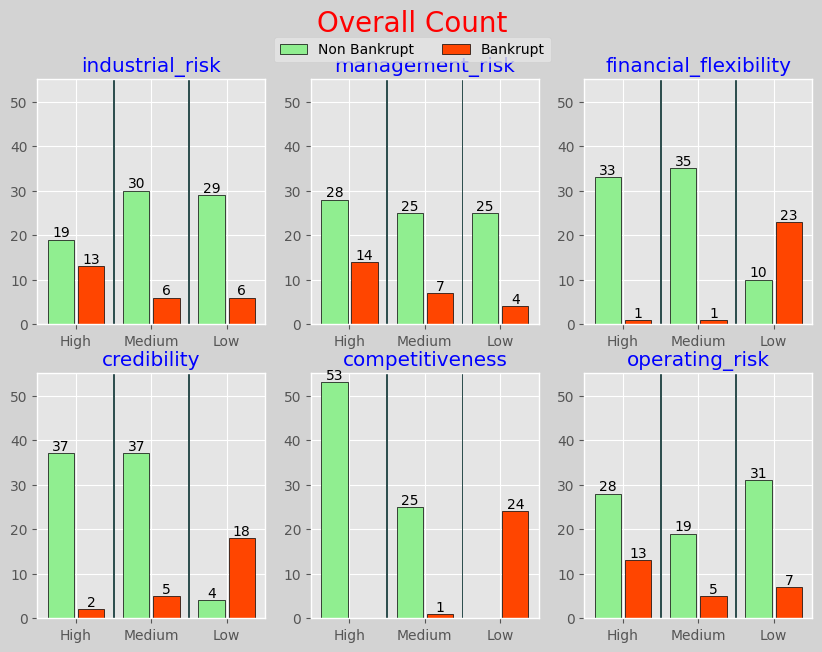

In [ ]:
# Visualisation
plt.figure(figsize=(10,7),facecolor='lightgrey')
plt.suptitle('Overall Count',size=20,color='red')
a=1
for i in dff.select_dtypes(['object']):
  plt.subplot(2,3,a)

  # Creating a temp table
  gr=dff.pivot_table(index=i,columns=dff['class'].astype(str),values='class',aggfunc=['count']).reindex(['High','Medium','Low']).reset_index()
  gr1=pd.DataFrame(data=gr)
  gr1.columns=gr1.columns.droplevel(1)
  gr1.columns=[i,'no bankruptcy','bankruptcy']

  # Visual
  plt.title(i,color='blue')
  x=np.arange(3)
  g=0.2 # Just to separate the 2 columns
  # Non Bankrupt
  nb=plt.bar(x-g,gr1['no bankruptcy'],0.35,color='lightgreen',edgecolor='black')
  plt.bar_label(nb)
  # Bankrupt
  b=plt.bar(x+g,gr1['bankruptcy'],0.35,color='orangered',edgecolor='black')
  plt.bar_label(b)
  plt.bar(x[:2]+0.5,55,0.025,color='darkslategrey') # Divider
  plt.xticks(x, ['High', 'Medium', 'Low'])
  plt.ylim(0,55)
  a+=1
plt.figlegend([nb,b],['Non Bankrupt','Bankrupt'],loc='upper center',ncol=2,bbox_to_anchor=(0.5, 0.95)) # Legend
plt.tight_layout(rect=[0,0,0,0.9])

In [ ]:
for x in dff.columns:
  print(x)
  print(dff[x].unique())

industrial_risk
['Medium' 'Low' 'High']
management_risk
['High' 'Low' 'Medium']
financial_flexibility
['Low' 'Medium' 'High']
credibility
['Low' 'Medium' 'High']
competitiveness
['Low' 'Medium' 'High']
operating_risk
['Medium' 'High' 'Low']
class
[1. 0.]


In [ ]:
df['class'].value_counts()
# The data is highly imballanced so relying on accuracy score is not feasible.
# We would focus mainly on Precision and Recall.

,count
class,
0.0,78
1.0,25


In [ ]:
# Creating feature and targets
feature=df.drop(columns='class')
target=df['class']

In [ ]:
# Checking the relation of features with the target
f_cl=f_classif(feature,target)
pd.DataFrame(np.array(f_cl).T,index=feature.columns,columns=['Corr','P value']).sort_values(by='P value',ascending=True)

,Corr,P value
competitiveness,286.377309,3.021905e-31
financial_flexibility,64.598608,1.789057e-12
credibility,58.724385,1.140213e-11
industrial_risk,4.997368,2.758723e-02
management_risk,3.736814,5.602610e-02
operating_risk,1.914511,1.695134e-01


In [ ]:
# Dropping column as its p values is more than 0.05
# Meaning it has a weak relation
feature.drop(columns='operating_risk',inplace=True)

In [ ]:
# Checking for multicolieanrity
vif=pd.DataFrame()
vif['features']=feature.columns
vif['vif']=[variance_inflation_factor(feature.values,x) for x in range(len(feature.columns))]
vif
# Since all have vif score less than 10 they are not multicolinear

,features,vif
0,industrial_risk,2.419238
1,management_risk,2.392699
2,financial_flexibility,3.586053
3,credibility,4.834866
4,competitiveness,5.449807


In [ ]:
# Splitting data into train and test data
x_train,x_test,y_train,y_test=train_test_split(feature,target,train_size=0.8,random_state=10)
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((82, 5), (21, 5), (82,), (21,))

# Model Building

In [ ]:
# Using Stratified Shuffle Split
shuf=StratifiedShuffleSplit(n_splits=5,train_size=0.8,random_state=10)

In [ ]:
# Creating Basic Models to start
log=LogisticRegression()
dt=DecisionTreeClassifier(criterion='gini',
                          splitter='best',
                          max_depth=3,
                          random_state=10)
rf=RandomForestClassifier(n_estimators=10,
                          criterion='gini',
                          max_depth=3,
                          bootstrap=True,
                          random_state=10)
ada=AdaBoostClassifier(estimator=log,
                       n_estimators=10,
                       random_state=10)
grad=GradientBoostingClassifier(n_estimators=10,
                                max_depth=3,
                                random_state=10)
xg=xgb.XGBClassifier(n_estimators=10,
                     max_depth=3)
lg=lgb.LGBMClassifier(n_estimators=10,
                      max_depth=3,
                      random_state=10,
                      verbose=-1)
bag=BaggingClassifier(log,
                      n_estimators=10,
                      bootstrap=True,
                      bootstrap_features=True,
                      random_state=10)

In [ ]:
model=[log,dt,rf,bag,ada,grad,xg,lg]

In [ ]:
print('                                                 Metrics Comparison')
print('='*115)
res=[]
metrics=['accuracy','precision','recall'] # Metrics to compare
for x in model:
  cross=cross_validate(x,x_train,y_train,scoring=metrics,return_train_score=True,cv=shuf)
  r={'Model':type(x).__name__}
  for m in metrics:
    r[f'Train {m}']=round(cross[f'train_{m}'].mean(),6)
    r[f'Test {m}']=round(cross[f'test_{m}'].mean(),6)
  res.append(r)
met=pd.DataFrame(res)
met.set_index('Model',inplace=True)
met
# Since we concluded that we would not use Accuracy Score as the data is imbalanced we can overlook the results of Accuracy
# Since we have to ensure that no bank get marked non bankrupt while its bankrupt
# That mean we need to avaoid a False Negative
# So we will Focus on Recall

# Apart from Adaboost almost all model are slightly overfit, whereas Adaboost is underfit
# We will rectify using Hyper parameter tuning

                                                 Metrics Comparison


,Train accuracy,Test accuracy,Train precision,Test precision,Train recall,Test recall
Model,,,,,,
LogisticRegression,0.978462,0.964706,1.000000,1.0,0.9125,0.85
DecisionTreeClassifier,0.990769,0.976471,1.000000,1.0,0.9625,0.90
RandomForestClassifier,0.996923,0.988235,0.988235,1.0,1.0000,0.95
BaggingClassifier,0.978462,0.964706,1.000000,1.0,0.9125,0.85
AdaBoostClassifier,0.901538,0.894118,0.600000,0.6,0.6000,0.55
GradientBoostingClassifier,0.990769,0.976471,1.000000,1.0,0.9625,0.90
XGBClassifier,0.990769,0.976471,1.000000,1.0,0.9625,0.90
LGBMClassifier,0.978462,0.964706,1.000000,1.0,0.9125,0.85


# Hyper Parameter Tuning

In [ ]:
def hyperparameter(model,params,x_train,y_train):
  grid=GridSearchCV(model,params,cv=10,scoring='recall') # As we want to avoid False Negative
  grid.fit(x_train,y_train)
  print(f'Model                    => {type(model).__name__}')
  print(f'Best Parameters          => {grid.best_params_}')
  print(f'Score of Best Parameters => {grid.best_score_}')
  print('='*60)

In [ ]:
# Selecting certain hyperparamters for the different models
log_p={'penalty':['l1','l2','elasticnet']}
dt_p={'criterion':['gini','entropy'],
      'max_depth':[1,2,3,4],
      'splitter':['random','best'],
      'random_state':[1,2,5,10,15,20,25]}
rf_p={'n_estimators':[1,2,5,10,15,20,25],
      'criterion':['gini','entropy'],
      'max_depth':[1,2,3,4],
      'random_state':[1,2,5,10,15,20,25]}
ada_p={'n_estimators':[1,2,5,10,15,20,25],
       'random_state':[1,2,5,10,15,20,25]}
grad_p={'n_estimators':[1,2,5,10,15,20,25],
        'max_depth':[1,2,3,4],
        'random_state':[1,2,5,10,15,20,25]}
xg_p={'n_estimators':[1,2,5,10,15,20,25],
      'max_depth':[1,2,3,4]}
lg_p={'n_estimators':[1,2,5,10,15,20,25],
      'max_depth':[1,2,3,4],
      'random_state':[1,2,5,10,15,20,25]}
bag_p={'n_estimators':[1,2,5,10,15,20,25],
       'random_state':[1,2,5,10,15,20,25]}

In [ ]:
params=[log_p,dt_p,rf_p,ada_p,grad_p,xg_p,lg_p,bag_p]
model=[log,dt,rf,ada,grad,xg,lg,bag]

In [ ]:
# Finding the Best Hyper Parameter
for x,y in zip(params,model):
  hyperparameter(y,x,x_train,y_train) # 6 Min

Model                    => LogisticRegression
Best Parameters          => {'penalty': 'l2'}
Score of Best Parameters => 0.9
Model                    => DecisionTreeClassifier
Best Parameters          => {'criterion': 'gini', 'max_depth': 1, 'random_state': 1, 'splitter': 'random'}
Score of Best Parameters => 0.95
Model                    => RandomForestClassifier
Best Parameters          => {'criterion': 'gini', 'max_depth': 2, 'n_estimators': 1, 'random_state': 15}
Score of Best Parameters => 1.0
Model                    => AdaBoostClassifier
Best Parameters          => {'n_estimators': 2, 'random_state': 1}
Score of Best Parameters => 0.8
Model                    => GradientBoostingClassifier
Best Parameters          => {'max_depth': 1, 'n_estimators': 5, 'random_state': 1}
Score of Best Parameters => 0.95
Model                    => XGBClassifier
Best Parameters          => {'max_depth': 1, 'n_estimators': 2}
Score of Best Parameters => 0.95
Model                    => LGBMClassifi

# Best Model

In [ ]:
log=LogisticRegression(penalty='l2')
dt=DecisionTreeClassifier(criterion='gini',
                          splitter='random',
                          max_depth=1,
                          random_state=1)
rf=RandomForestClassifier(n_estimators=1,
                          criterion='gini',
                          max_depth=2,
                          bootstrap=True,
                          random_state=15)
ada=AdaBoostClassifier(estimator=log,
                       n_estimators=2,
                       random_state=1)
grad=GradientBoostingClassifier(n_estimators=5,
                                max_depth=1,
                                random_state=1)
xg=xgb.XGBClassifier(n_estimators=2,
                     max_depth=1)
lg=lgb.LGBMClassifier(n_estimators=10,
                      max_depth=1,
                      random_state=1,
                      verbose=-1)
bag=BaggingClassifier(log,
                      n_estimators=1,
                      bootstrap=True,
                      bootstrap_features=True,
                      random_state=2)

In [ ]:
model=[log,dt,rf,ada,grad,xg,lg,bag]

In [ ]:
# Calculating Recall for both classes for all Model
res=[]
for x in model:
  x.fit(x_train,y_train)
  y_pred=x.predict(x_test)
  _,recall,_,_=precision_recall_fscore_support(y_test,y_pred)
  r={'Model':type(x).__name__}
  r['Class 0']=recall[0]
  r['Class 1']=recall[1]
  res.append(r)
comp=pd.DataFrame(res).set_index('Model')
comp

,Class 0,Class 1
Model,,
LogisticRegression,1.0000,1.0
DecisionTreeClassifier,1.0000,1.0
RandomForestClassifier,1.0000,1.0
AdaBoostClassifier,0.9375,1.0
GradientBoostingClassifier,1.0000,1.0
XGBClassifier,1.0000,1.0
LGBMClassifier,1.0000,1.0
BaggingClassifier,1.0000,1.0


In [ ]:
def models(model,x_train,y_train,x_test,y_test):
  model.fit(x_train,y_train)
  y_pred=model.predict(x_test)
  prob=model.predict_proba(x_test)
  for i,t in zip([0,1],['Non Bankrupt','Bankrupt']):
    lab=(y_test==i).astype(int)
    auc=roc_auc_score(lab,prob[:,i])
    fpr,tpr,_=roc_curve(lab,prob[:,i])
    plt.plot(fpr,tpr,label=f'Class {i}\nAUC={auc:.3f}')
    plt.plot([0,1],linestyle='--')
    plt.title(f'ROC CURVES for {type(model).__name__}',size=15,color='blue')
    plt.legend()
    plt.tight_layout()

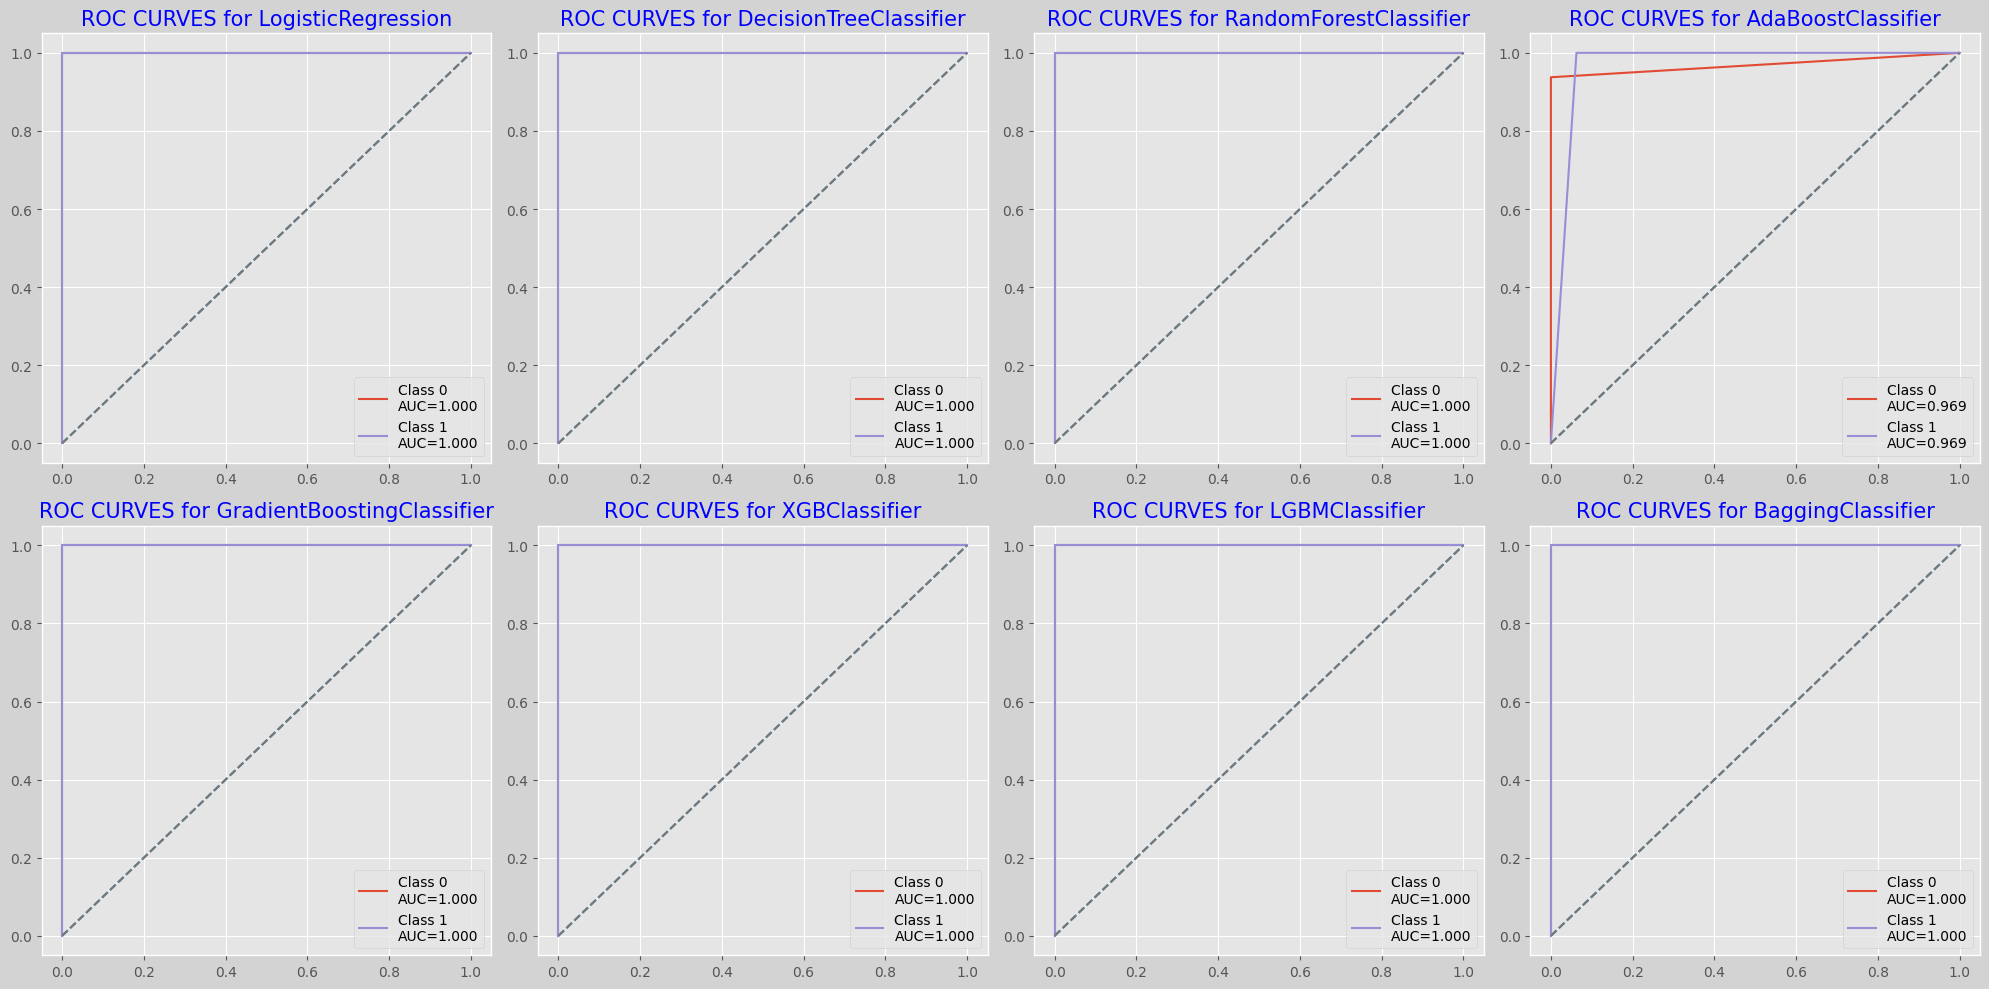

In [ ]:
# Preparing the ROC curves for each Model
p=1
plt.figure(figsize=(20,10),facecolor='lightgrey')
for x in model:
  plt.subplot(2,4,p)
  models(x,x_train,y_train,x_test,y_test)
  p+=1
plt.tight_layout()

In [ ]:
log.fit(x_train,y_train)
dt.fit(x_train,y_train)
rf.fit(x_train,y_train)
ada.fit(x_train,y_train)
grad.fit(x_train,y_train)
xg.fit(x_train,y_train)
lg.fit(x_train,y_train)
bag.fit(x_train,y_train)

models=[log,dt,rf,ada,grad,xg,lg,bag]

In [ ]:
# Testing the models
ind=float(input('Industial Risk => '))
mg=float(input('Management Risk => '))
fin=float(input('Financial Flexibility => '))
cred=float(input('Credibility => '))
com=float(input('Competitiveness => '))
test={'industrial_risk':ind,
      'management_risk':mg,
      'financial_flexibility':fin,
      'credibility':cred,
      'competitiveness':com}
t=pd.DataFrame([test])
print('='*30)
print('Predictions')
print('='*30)
for x in models:
  ans=x.predict(t)
  print(f'{type(x).__name__}    => {ans}')

Industial Risk => 1
Management Risk => 1
Financial Flexibility => 1
Credibility => 0
Competitiveness => 0.5
Predictions
LogisticRegression    => [0.]
DecisionTreeClassifier    => [0.]
RandomForestClassifier    => [1.]
AdaBoostClassifier    => [1.]
GradientBoostingClassifier    => [0.]
XGBClassifier    => [0]
LGBMClassifier    => [0.]
BaggingClassifier    => [0.]


\# Deployment

In [ ]:
# Creating pickle files for all Models
l='log.pkl'
pickle.dump(log,open(l,'wb'))
d='dtree.pkl'
pickle.dump(dt,open(d,'wb'))
r='rfor.pkl'
pickle.dump(rf,open(r,'wb'))
a='adab.pkl'
pickle.dump(ada,open(a,'wb'))
g='grad.pkl'
pickle.dump(grad,open(g,'wb'))
x='xgb.pkl'
pickle.dump(xg,open(x,'wb'))
l_g='lgb.pkl'
pickle.dump(lg,open(l_g,'wb'))
b='bagg.pkl'
pickle.dump(bag,open(b,'wb'))

In [ ]:
ngrok_key=getpass.getpass('Enter ngrok Key => ')

Enter ngrok Key => ··········


In [ ]:
# 36eTGiTQZuWnYIl3RraaomYmBoZ_2SHXLvPU6H8YrGwT1SmkD

In [ ]:
%%writefile deploy.py
import sklearn
import streamlit as st
import pickle
import pandas as pd

# Loading all pickle files
l=pickle.load(open('log.pkl','rb'))
d=pickle.load(open('dtree.pkl','rb'))
r=pickle.load(open('rfor.pkl','rb'))
a=pickle.load(open('adab.pkl','rb'))
g=pickle.load(open('grad.pkl','rb'))
x=pickle.load(open('xgb.pkl','rb'))
l_g=pickle.load(open('lgb.pkl','rb'))
b=pickle.load(open('bagg.pkl','rb'))

st.title('Bankruptcy Prevention Project')

# Input Parameters
def input_feature():
  c1,c2,c3=st.columns([1,1,1])
  with c1:
    ind=st.radio('Industrial Risk',('High','Medium','Low'))
    mgmt=st.radio('Managaement Risk',('High','Medium','Low'))
  with c2:
    fin=st.radio('Financial Flexibility',('High','Medium','Low'))
    cred=st.radio('Credibility',('High','Medium','Low'))
  with c3:
    comp=st.radio('Competitiveness',('High','Medium','Low'))
    # opr=st.radio('Operating Risk',('High','Medium','Low'))
  inp={'industrial_risk':ind,'management_risk':mgmt,'financial_flexibility':fin,'credibility':cred,'competitiveness':comp}
  # ,'operating_risk':opr}
  df=pd.DataFrame([inp]) # Converting to a Table
  # Mapping the columns
  df['industrial_risk']=df['industrial_risk'].map({'High':1,'Medium':0.5,'Low':0})
  df['management_risk']=df['management_risk'].map({'High':1,'Medium':0.5,'Low':0})
  df['financial_flexibility']=df['financial_flexibility'].map({'High':1,'Medium':0.5,'Low':0})
  df['credibility']=df['credibility'].map({'High':1,'Medium':0.5,'Low':0})
  df['competitiveness']=df['competitiveness'].map({'High':1,'Medium':0.5,'Low':0})
  # df['operating_risk']=df['operating_risk'].map({'High':1,'Medium':0.5,'Low':0})
  return df
st.divider()
y=input_feature()
c1,c2=st.columns([1,1])
with c1:
  # Selection of Model
  model={'LogisticRegression':l,'Decision Tree':d,'Random Forest':r,'Ada Boost':a,'Gradient Boost':g,'Extreme Gradient Boost':x,'Light Gradient Boost':l_g,'Bagging':b}
  m=st.selectbox('Choose a Model for Prediction',list(model.keys()))
  md=model[m]
  # Prediction
  pred=md.predict(y)
  prob=md.predict_proba(y)
  button=st.button('Prediction')
with c2:
  if button is True:
    st.subheader('Prediction')
    st.write('Bankrupt' if prob[0][1]>0.5 else 'Not Bankrupt') # Output
    # Confidence Level
    if prob[0][0]>prob[0][1]:
      st.write(f'With confidence of {round(prob[0][0],4)*100}%')
    else:
      st.write(f'With confidence of {round(prob[0][1],4)*100}%')

Overwriting deploy.py


In [ ]:
from pyngrok import ngrok
port=8501
ngrok.set_auth_token(ngrok_key)
ngrok.connect(port).public_url

'https://unsulfureous-camelia-superethically.ngrok-free.dev'

In [ ]:
  !rm -f logs.txt && streamlit run deploy.py >/content/logs.txt 2>&1

# Deployed File

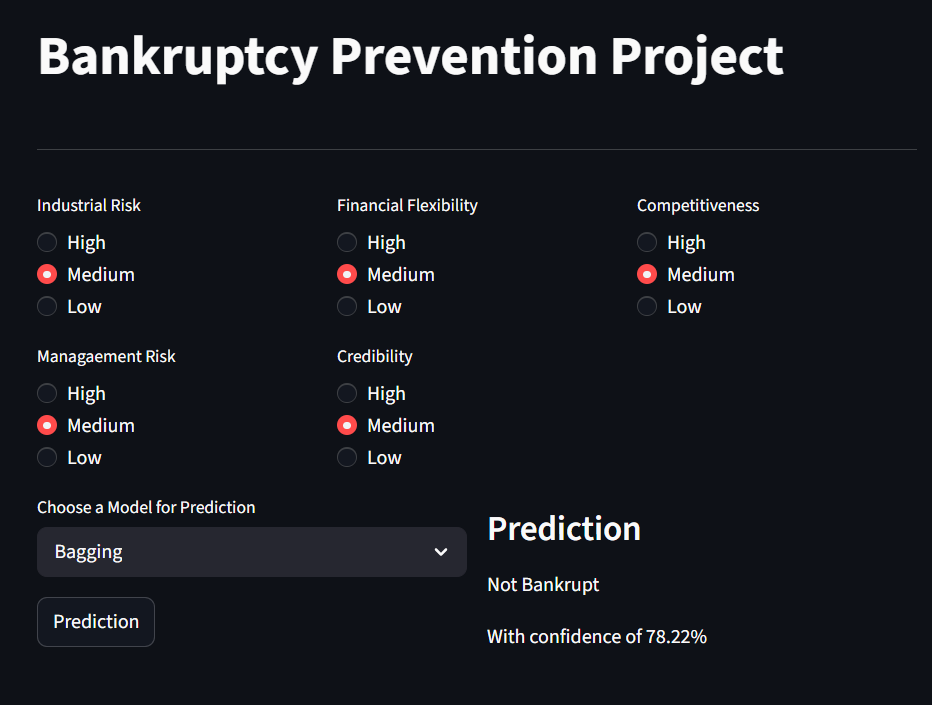

# THE END